
количество вершин: 34

количество ребер: 78

первые несколько вершин и их атрибуты:
[(0, {'club': 'Mr. Hi'}), (1, {'club': 'Mr. Hi'}), (2, {'club': 'Mr. Hi'}), (3, {'club': 'Mr. Hi'}), (4, {'club': 'Mr. Hi'})]

первые строки таблицы признаков:
   node  degree  clustering  betweenness  closeness  eigenvector true_club  \
0     0      16    0.150000     0.437635   0.568966     0.355483    Mr. Hi   
1     1       9    0.333333     0.053937   0.485294     0.265954    Mr. Hi   
2     2      10    0.244444     0.143657   0.559322     0.317189    Mr. Hi   
3     3       6    0.666667     0.011909   0.464789     0.211174    Mr. Hi   
4     4       3    0.666667     0.000631   0.379310     0.075966    Mr. Hi   

   true_label  
0           0  
1           0  
2           0  
3           0  
4           0  

информация о таблице:
<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ----------

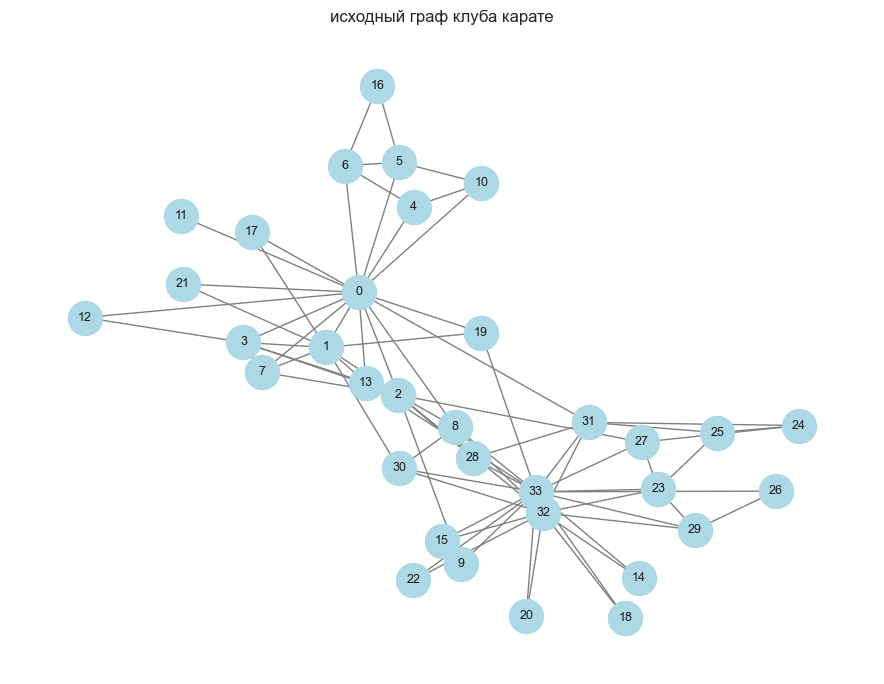

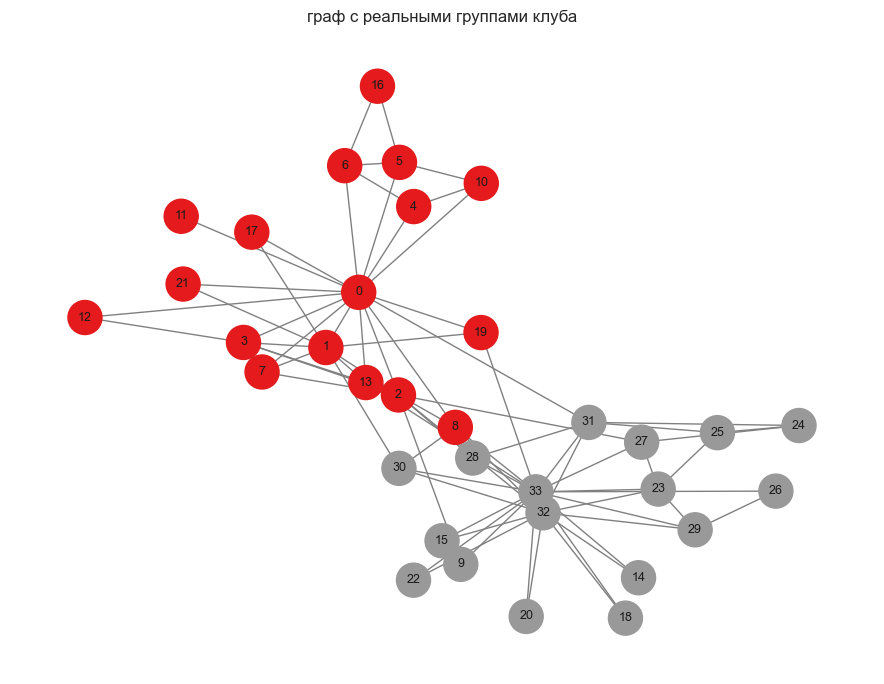

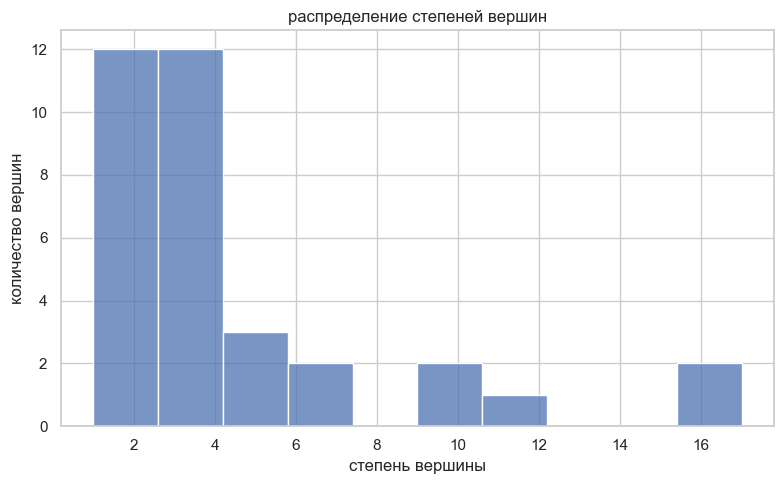

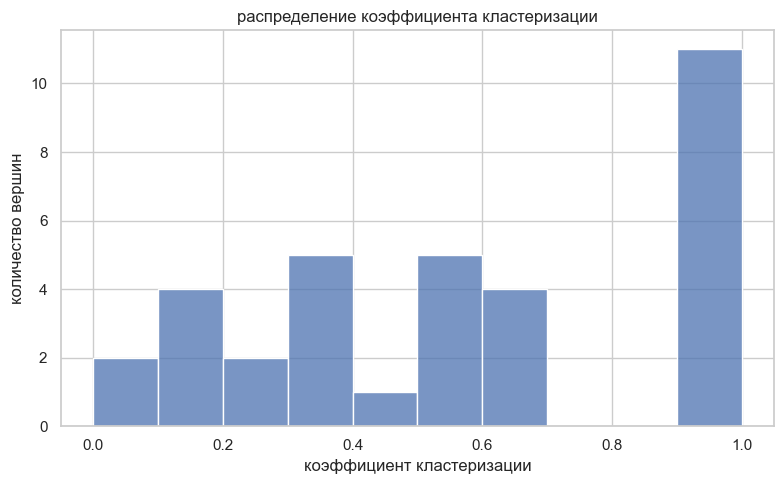

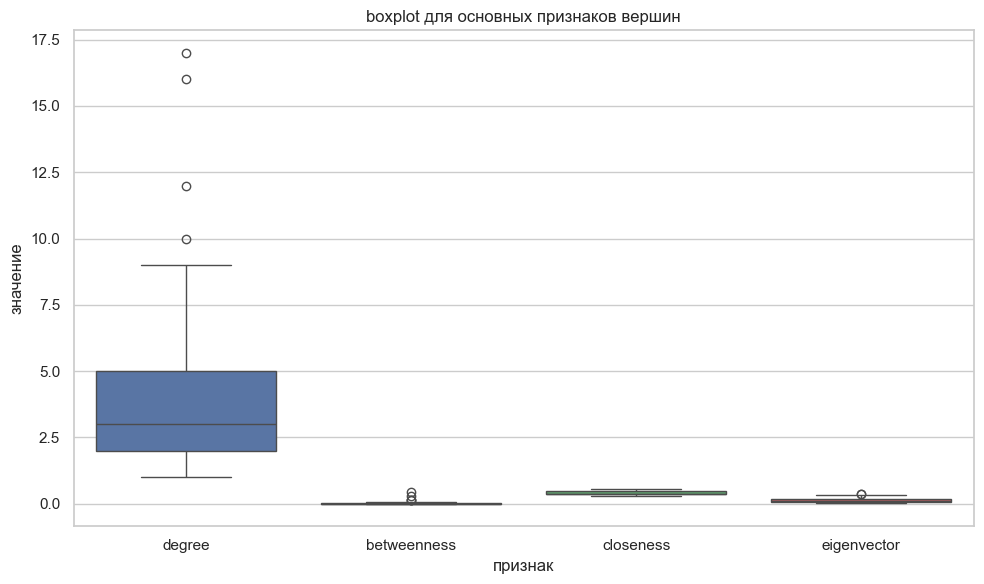

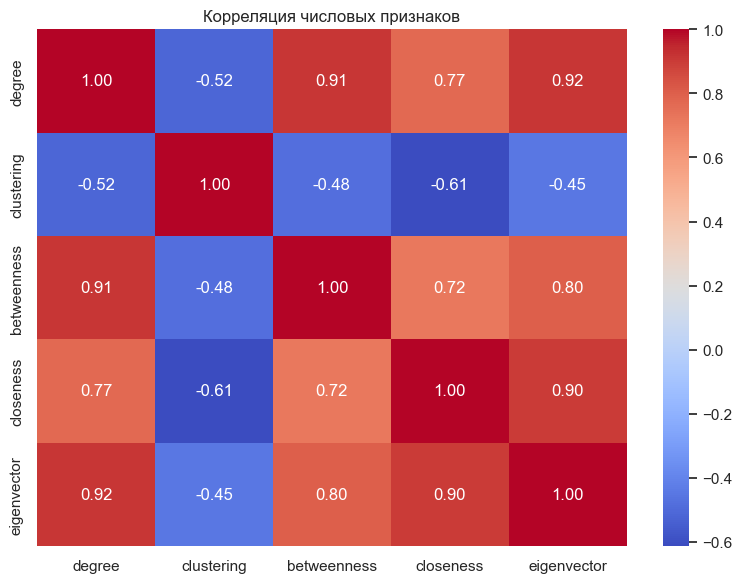

                 model       ARI       NMI  Silhouette  Modularity  \
0               KMeans -0.008147  0.015655    0.521820   -0.042962   
1  Spectral Clustering  0.771725  0.732378   -0.025581    0.347660   

   Accuracy_for_explanation                                           comment  
0                  0.558824  Модель работает по рассчитанным признакам вершин  
1                  0.941176           Модель работает по матрице связей графа  


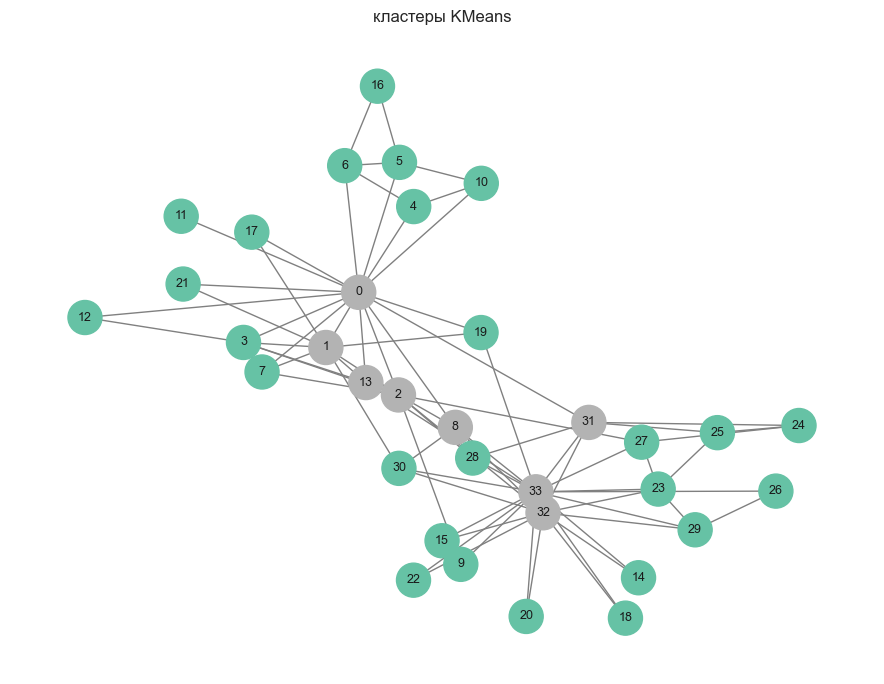

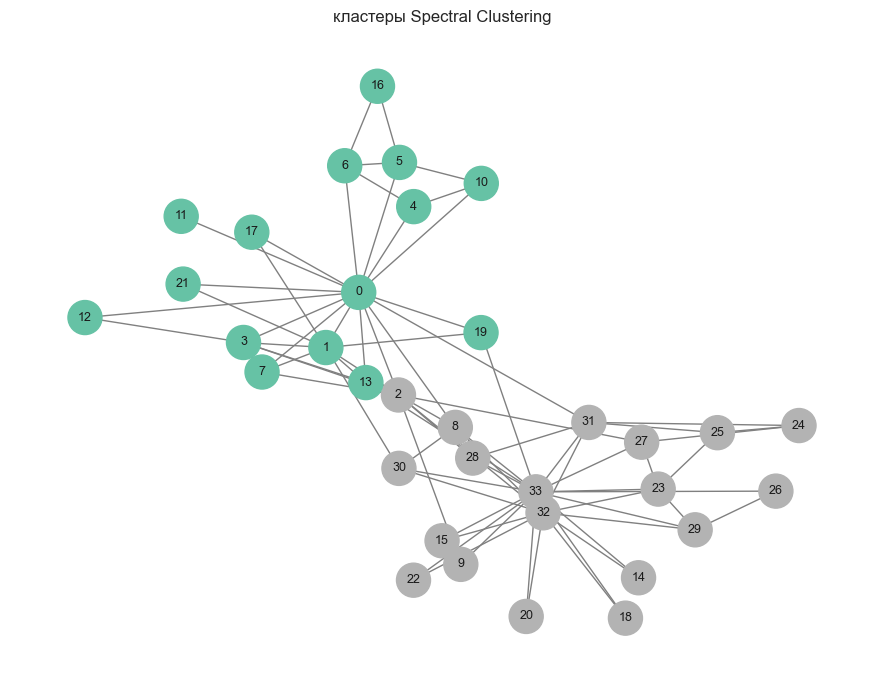

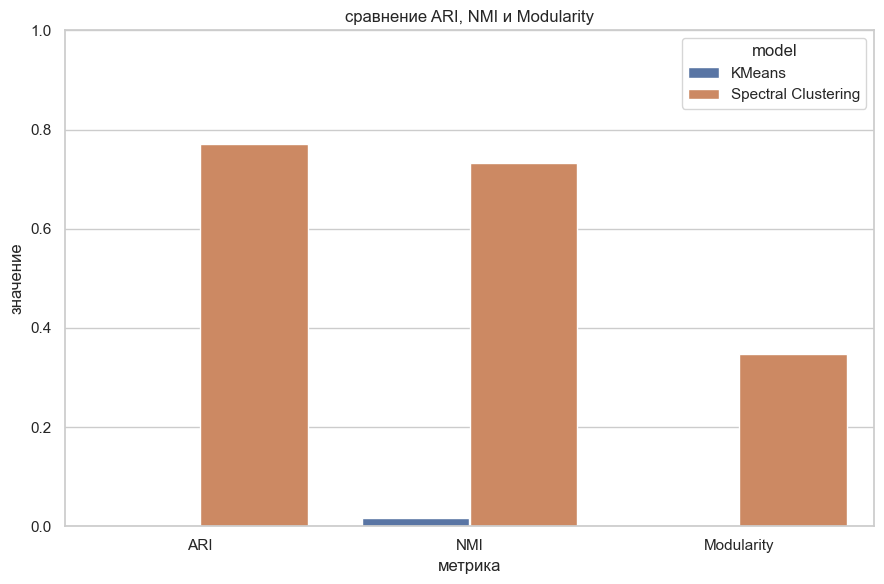

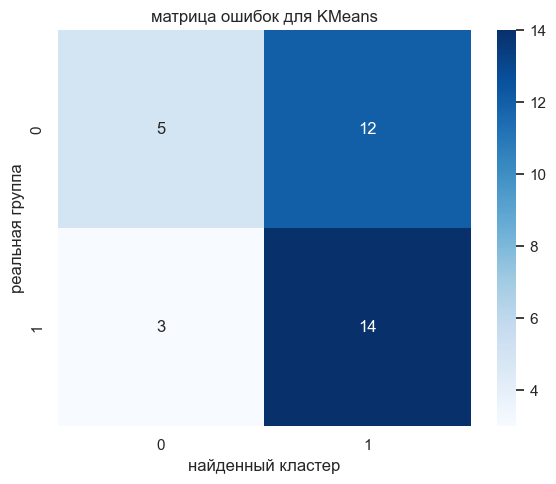

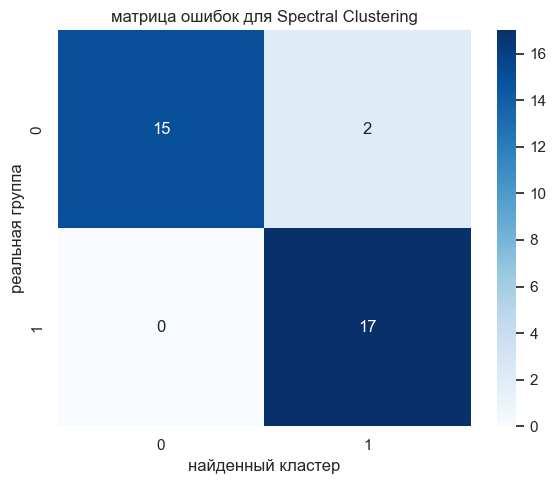


средние значения признаков по кластерам KMeans:
                   degree  clustering  betweenness  closeness  eigenvector
kmeans_cluster                                                            
0                2.923077     0.65641     0.006600   0.394187     0.104324
1               10.000000     0.29188     0.165577   0.531430     0.283195

средние значения признаков по кластерам Spectral Clustering:
                    degree  clustering  betweenness  closeness  eigenvector
spectral_cluster                                                           
0                 4.400000    0.627778     0.042870   0.418178     0.135625
1                 4.736842    0.525529     0.044903   0.433033     0.154927

еоличество вершин: 77
Количество ребер: 254

первые несколько вершин и их атрибуты
[(0, {'name': 'Napoleon'}), (1, {'name': 'Myriel'}), (2, {'name': 'MlleBaptistine'}), (3, {'name': 'MmeMagloire'}), (4, {'name': 'CountessDeLo'})]

первые строки таблицы Les Miserables
   node         

In [3]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from networkx.algorithms.community.quality import modularity


def labels_to_communities(labels):
    # эта функция переводит номера кластеров в сообщества для networkx. было [0, 0, 1, 1] станет [{0, 1}, {2, 3}]
    communities = []

    # np.unique(labels) находит все разные номера кластеров
    for cluster_number in np.unique(labels):
        community = set()

        # enumerate(labels) дает сразу номер вершины и номер её кластера
        for node, label in enumerate(labels):
            if label == cluster_number:
                community.add(node)

        communities.append(community)

    return communities


def fix_labels_for_confusion(y_true, labels):
    # в кластеризации номера кластеров могут поменяться местами например, настоящая группа 0 может стать кластером 1 просто номера кластеров условные
    labels = np.array(labels)

    # accuracy_score считает долю совпавших ответов
    accuracy_normal = accuracy_score(y_true, labels)

    # для двух кластеров 1 - labels меняет 0 на 1, а 1 на 0
    reversed_labels = 1 - labels
    accuracy_reversed = accuracy_score(y_true, reversed_labels)

    # оставляем тот вариант номеров, где совпадение с реальными метками больше
    if accuracy_reversed > accuracy_normal:
        return reversed_labels
    else:
        return labels


def main():
    sns.set(style="whitegrid")

    # сюда будем сохранять картинки для отчета
    os.makedirs("plots", exist_ok=True)

    # грузим основной датасет

    # nx.karate_club_graph() загружает готовый граф Zachary's Karate Club
    G = nx.karate_club_graph()

    # Вершины графа - участники клуба. ребра графа - взаимодействия между участниками. в графе есть реальные метки club: "Mr. Hi" и "Officer". они показывают фактический раскол клуба на две группы. эти метки нельзя использовать при обучении моделей. Их можно использовать только потом для проверки качества кластеризации

    # G.number_of_nodes() считает количество вершин в графе
    print("\nколичество вершин:", G.number_of_nodes())

    # G.number_of_edges() считает количество ребер в графе
    print("\nколичество ребер:", G.number_of_edges())

    print("\nпервые несколько вершин и их атрибуты:")
    # list(G.nodes(data=True)) превращает вершины с атрибутами в обычный список
    # [:5] берёт первые 5 элементов списка
    print(list(G.nodes(data=True))[:5])

    # + реальные метки но не даем их моделям
    y_true = []

    # G.nodes() возвращает вершины графа
    for node in G.nodes():
        # G.nodes[node]["club"] достает реальную группу конкретной вершины
        club_name = G.nodes[node]["club"]

        # эти метки не даем моделям, они нужны только для проверки результата
        if club_name == "Mr. Hi":
            y_true.append(0)
        else:
            y_true.append(1)

    # np.array превращает обычный список в массив numpy, с ним удобно считать метрики
    y_true = np.array(y_true)

    # анализ графа и признаки вершин

    # считаем степень каждой вершины, то есть сколько у нее связей
    # G.degree() дает степени вершин, dict делает обычный словарь, pd.Series превращает его в столбец pandas
    degree = pd.Series(dict(G.degree()))

    # считаем коэффициент кластеризации для каждой вершины
    # он показывает, насколько соседи вершины связаны между собой
    clustering = pd.Series(nx.clustering(G))

    # считаем центральность посредничества: важность вершины как "моста"
    # если вершина часто лежит на кратчайших путях между другими, значение будет больше
    betweenness = pd.Series(nx.betweenness_centrality(G))

    # считаем близость вершины ко всем остальным вершинам графа
    # чем значение больше, тем в среднем ближе вершина к другим вершинам
    closeness = pd.Series(nx.closeness_centrality(G))

    # считаем eigenvector centrality
    # она выше, если вершина связана с другими важными вершинами
    eigenvector = pd.Series(nx.eigenvector_centrality(G, max_iter=1000))

    # pd.DataFrame создает таблицу pandas из словаря столбцов
    df = pd.DataFrame({"node": list(G.nodes()), "degree": degree, "clustering": clustering, "betweenness": betweenness, "closeness": closeness, "eigenvector": eigenvector, "true_club": [G.nodes[node]["club"] for node in G.nodes()], "true_label": y_true })

    print("\nпервые строки таблицы признаков:")
    # df.head() показывает первые 5 строк таблицы
    print(df.head())

    print("\nинформация о таблице:")
    # df.info() показывает типы столбцов и есть ли пропуски
    print(df.info())

    print("\nописание числовых признаков:")
    # df.describe() показывает среднее, минимум, максимум и другие статистики
    print(df.describe())

    print("\nпроверка пропусков:")
    # isna() проверяет, где в таблице пустые значения
    # sum() считает количество пустых значений в каждом столбце
    print(df.isna().sum())

    # to_csv сохраняет таблицу в csv-файл
    # index=False значит, что отдельный столбец с индексами pandas сохранять не надо
    df.to_csv("карате_признаки.csv", index=False)

    # это  "паспорт набора данных"
    # его в csv, чтобы потом можно было вставить в отчет норм
    dataset_passport = pd.DataFrame({
        "Характеристика": ["Название датасета", "Источник", "Количество наблюдений", "Количество признаков", "Тип задачи", "Целевая переменная", "Количество числовых признаков", "Количество категориальных признаков", "Наличие пропусков", "Предварительный вывод"],
        "Значение": ["Zachary's Karate Club", "NetworkX", G.number_of_nodes(), 5, "Кластеризация, обучение без учителя","Нет целевой переменной для обучения; club используется только для проверки", 5, 1, int(df.isna().sum().sum()), "Данные маленькие, чистые, подходят для учебной кластеризации графа"]
    })

    dataset_passport.to_csv("dataset_passport.csv", index=False)

    # это "журнал предобработки данных"
    preprocessing_log = pd.DataFrame({
        "Шаг": ["Обработка пропусков", "Обработка выбросов", "Кодирование категорий", "Масштабирование признаков", "Разделение на выборки","Балансировка классов"],
        "Действие": ["Проверили df.isna().sum(), пропусков нет", "Построили boxplot, значения оставили как есть", "Реальные группы club перевели в 0 и 1 только для оценки качества", "Использовали StandardScaler для признаков вершин", "Не делали train/test, потому что это кластеризация без учителя", "Не делали, потому что это не задача классификации"],
        "Инструменты/метод": ["pandas isna, sum", "seaborn boxplot", "обычный if в цикле", "sklearn StandardScaler", "не требуется", "не требуется"],
        "Обоснование": ["Моделям нужны заполненные признаки", "В графах вершины с большой степенью могут быть важными участниками, удалять их нельзя", "Модели эти метки не видят, они нужны только для проверки", "KMeans чувствителен к масштабу признаков","У нас нет целевой переменной для обучения", "Кластеры модель ищет сама"]
    })

    preprocessing_log.to_csv("preprocessing_log.csv", index=False)

    # графики для EDA

    # spring_layout считает координаты вершин так, чтобы связанные вершины были ближе
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(9, 7))
    # рисуем исходный граф без учета групп, просто для структуры сети короче
    nx.draw_networkx(G, pos=pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=600, font_size=9)

    plt.title("исходный граф клуба карате")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("plots/структура_сети.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 7))
    # этот граф показывает реальные группы, но они нужны только для анализа результата
    nx.draw_networkx(G, pos=pos, with_labels=True, node_color=y_true, cmap=plt.cm.Set1, edge_color="gray", node_size=600, font_size=9 )
    
    plt.title("граф с реальными группами клуба")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("plots/тру_группы.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    # гистограмма показывает, у скольких вершин мало или много связей
    sns.histplot(df["degree"], bins=10, kde=False)
    plt.title("распределение степеней вершин")
    plt.xlabel("степень вершины")
    plt.ylabel("количество вершин")
    plt.tight_layout()
    plt.savefig("plots/гистограмма_степеней.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    # гистограмма показывает, насколько часто соседи вершин связаны между собой
    sns.histplot(df["clustering"], bins=10, kde=False)
    plt.title("распределение коэффициента кластеризации")
    plt.xlabel("коэффициент кластеризации")
    plt.ylabel("количество вершин")
    plt.tight_layout()
    plt.savefig("plots/гистограмма_кластеризации.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 6))
    # boxplot помогает увидеть разброс признаков и выбросы
    sns.boxplot(data=df[["degree", "betweenness", "closeness", "eigenvector"]])
    plt.title("boxplot для основных признаков вершин")
    plt.xlabel("признак")
    plt.ylabel("значение")
    plt.tight_layout()
    plt.savefig("plots/boxplot_признаков.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 6))
    # corr() считает корреляции между числовыми признаками
    # heatmap показывает эти корреляции цветом
    corr = df[["degree", "clustering", "betweenness", "closeness", "eigenvector"]].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Корреляция числовых признаков")
    plt.tight_layout()
    plt.savefig("plots/06_corr_heatmap.png", dpi=300)
    plt.show()

    # готовим признаки для моделей

    # берем из таблицы только эти столбцы как признаки для модели
    # это таблица признаков, по ней KMeans будет искать похожие вершины
    X = df[["degree", "clustering", "betweenness", "closeness", "eigenvector"]]

    # StandardScaler будет приводить признаки к одному масштабу
    scaler = StandardScaler()

    # fit_transform сначала считает среднее и стандартное отклонение, а потом преобразует признаки. масштабируем. масштабирование нужно, чтобы признаки с большими числами не задавили остальные признаки
    X_scaled = scaler.fit_transform(X)

    # 1 модель - KMeans

    # KMeans делит объекты на группы по похожести числовых признаков
    # здесь объект - вершина графа, а признаки - degree, clustering и центральности
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

    # fit_predict обучает модель и сразу возвращает номера кластеров
    kmeans_labels = kmeans.fit_predict(X_scaled)

    # 2 модель - Spectral Clustering

    # превращаем граф в матрицу смежности: 1 означает, что связь между вершинами есть, 0 - связи нет
    # если A[i][j] = 1, значит между вершинами i и j есть связь
    # если A[i][j] = 0, значит связи нет
    A = nx.to_numpy_array(G, weight=None)

    # Spectral Clustering работает не просто с признаками вершин, а со структурой связей графа
    # поэтому для графовой кластеризации он часто выглядит более естественно, чем KMeans
    spectral = SpectralClustering(n_clusters=2, affinity="precomputed", random_state=42)

    # fit_predict обучает модель на матрице связей и возвращает номера кластеров
    spectral_labels = spectral.fit_predict(A)

    # добавляем найденные кластеры в таблицу, чтобы было удобно смотреть результат
    df["kmeans_cluster"] = kmeans_labels
    df["spectral_cluster"] = spectral_labels

    # метрики качества

    # ARI сравнивает найденные кластеры с реальными метками. 1 означает полное совпадение, около 0 - примерно случайный результат
    kmeans_ari = adjusted_rand_score(y_true, kmeans_labels)
    spectral_ari = adjusted_rand_score(y_true, spectral_labels)

    # NMI показывает, насколько много общей информации между реальными группами и найденными кластерами. 1 означает полное совпадение
    kmeans_nmi = normalized_mutual_info_score(y_true, kmeans_labels)
    spectral_nmi = normalized_mutual_info_score(y_true, spectral_labels)

    # silhouette показывает, насколько объекты внутри кластера похожи друг на друга и отделены от других кластеров. чем ближе к 1, тем лучше
    kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

    # для Spectral Clustering считаем silhouette по X_scaled только как дополнительную оценку
    spectral_silhouette = silhouette_score(X_scaled, spectral_labels)

    # modularity показывает, насколько хорошо граф разбился на сообщества. если внутри кластеров много связей, а между кластерами мало, модулярность выше. вообще кайф это очень подходящая метрика именно для графовой кластеризации
    kmeans_modularity = modularity(G, labels_to_communities(kmeans_labels))
    spectral_modularity = modularity(G, labels_to_communities(spectral_labels))

    # это нужно только для красивой матрицы ошибок. ARI и NMI сами не зависят от перестановки номеров кластеров
    kmeans_labels_fixed = fix_labels_for_confusion(y_true, kmeans_labels)
    spectral_labels_fixed = fix_labels_for_confusion(y_true, spectral_labels)

    kmeans_accuracy = accuracy_score(y_true, kmeans_labels_fixed)
    spectral_accuracy = accuracy_score(y_true, spectral_labels_fixed)

    # confusion_matrix строит таблицу: сколько объектов какого настоящего класса попали в какой кластер
    kmeans_cm = confusion_matrix(y_true, kmeans_labels_fixed)
    spectral_cm = confusion_matrix(y_true, spectral_labels_fixed)

    # pd.DataFrame создает итоговую таблицу сравнения моделей
    results_df = pd.DataFrame({"model": ["KMeans", "Spectral Clustering"], "ARI": [kmeans_ari, spectral_ari], "NMI": [kmeans_nmi, spectral_nmi], "Silhouette": [kmeans_silhouette, spectral_silhouette], "Modularity": [kmeans_modularity, spectral_modularity], "Accuracy_for_explanation": [kmeans_accuracy, spectral_accuracy], "comment": ["Модель работает по рассчитанным признакам вершин", "Модель работает по матрице связей графа"]})

    print(results_df)
    results_df.to_csv("результаты_моделей.csv", index=False)

    # результатики 

    plt.figure(figsize=(9, 7))
    # этот граф показывает, какие кластеры нашёл KMeans
    nx.draw_networkx(G,pos=pos, with_labels=True, node_color=kmeans_labels, cmap=plt.cm.Set2, edge_color="gray", node_size=600,font_size=9)
    plt.title("кластеры KMeans")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("plots/граф_kmeans.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 7))
    # этот граф показывает, какие кластеры нашёл Spectral Clustering
    nx.draw_networkx(G, pos=pos, with_labels=True, node_color=spectral_labels, cmap=plt.cm.Set2, edge_color="gray", node_size=600, font_size=9 )
    plt.title("кластеры Spectral Clustering")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("plots/граф_spectral.png", dpi=300)
    plt.show()

    # melt переводит таблицу из широкого вида в длинный так seaborn проще строит несколько метрик на одном барплоте
    metrics_for_plot = results_df[["model", "ARI", "NMI", "Modularity"]]
    metrics_long = metrics_for_plot.melt(id_vars="model", var_name="metric", value_name="value")

    plt.figure(figsize=(9, 6))
    # барплот сравнивает значения метрик у двух моделей
    sns.barplot(data=metrics_long, x="metric", y="value", hue="model")
    plt.title("сравнение ARI, NMI и Modularity")
    plt.xlabel("метрика")
    plt.ylabel("значение")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig("plots/сравнение_метрик.png", dpi=300)
    plt.show()

    plt.figure(figsize=(6, 5))
    # heatmap для confusion matrix показывает ошибки цветом
    sns.heatmap(kmeans_cm, annot=True, fmt="d", cmap="Blues")
    plt.title("матрица ошибок для KMeans")
    plt.xlabel("найденный кластер")
    plt.ylabel("реальная группа")
    plt.tight_layout()
    plt.savefig("plots/матрица_ошибок_kmeans.png", dpi=300)
    plt.show()

    plt.figure(figsize=(6, 5))
    # здесь такая же матрица ошибок, но для Spectral Clustering
    sns.heatmap(spectral_cm, annot=True, fmt="d", cmap="Blues")
    plt.title("матрица ошибок для Spectral Clustering")
    plt.xlabel("найденный кластер")
    plt.ylabel("реальная группа")
    plt.tight_layout()
    plt.savefig("plots/матрица_ошибок_spectral.png", dpi=300)
    plt.show()

    # интерпретанция кластеров

    # у моделей кластеризации нет обычного feature_importances_ поэтому чекаем чем кластеры отличаются по средним значениям признаков
    kmeans_cluster_profile = df.groupby("kmeans_cluster")[["degree", "clustering", "betweenness", "closeness", "eigenvector"]].mean()

    spectral_cluster_profile = df.groupby("spectral_cluster")[["degree", "clustering", "betweenness", "closeness", "eigenvector"]].mean()

    print("\nсредние значения признаков по кластерам KMeans:")
    print(kmeans_cluster_profile)

    print("\nсредние значения признаков по кластерам Spectral Clustering:")
    print(spectral_cluster_profile)

    kmeans_cluster_profile.to_csv("kmeans_профиль_кластеров.csv")
    spectral_cluster_profile.to_csv("spectral_профиль_кластеров.csv")

    # допдатасет Les Miserables. вершины - персонажи. ребра - совместные появления персонажей. здесь нет удобных истинных меток, как в карате поэтому считаем только внутренние метрики: Silhouette и Modularity

    # nx.les_miserables_graph() загружает готовую сеть персонажей
    G2_original = nx.les_miserables_graph()

    # convert_node_labels_to_integers заменяет имена персонажей на номера 0, 1, 2 и тд
    # старое имя сохраняем в атрибуте name, чтобы граф норм работал с labels_to_communities()
    G2 = nx.convert_node_labels_to_integers(G2_original, label_attribute="name")

    print("\nеоличество вершин:", G2.number_of_nodes())
    print("Количество ребер:", G2.number_of_edges())
    print("\nпервые несколько вершин и их атрибуты")
    print(list(G2.nodes(data=True))[:5])

    degree2 = pd.Series(dict(G2.degree()))
    clustering2 = pd.Series(nx.clustering(G2))
    betweenness2 = pd.Series(nx.betweenness_centrality(G2))
    closeness2 = pd.Series(nx.closeness_centrality(G2))
    eigenvector2 = pd.Series(nx.eigenvector_centrality(G2, max_iter=1000))

    df2 = pd.DataFrame({
        "node": list(G2.nodes()),
        "name": [G2.nodes[node]["name"] for node in G2.nodes()], "degree": degree2, "clustering": clustering2, "betweenness": betweenness2, "closeness": closeness2, "eigenvector": eigenvector2})

    print("\nпервые строки таблицы Les Miserables")
    print(df2.head())

    df2.to_csv("les_miserables_данные.csv", index=False)

    X2 = df2[["degree", "clustering", "betweenness", "closeness", "eigenvector"]]

    scaler2 = StandardScaler()
    X2_scaled = scaler2.fit_transform(X2)

    # для Les Miserables берем 4 кластера, потому что персонажей больше, чем в Karate Club это просто фор фан выбор, чтобы показать работу подхода на другом графе
    les_clusters = 4

    kmeans2 = KMeans(n_clusters=les_clusters, random_state=42, n_init=10)
    kmeans2_labels = kmeans2.fit_predict(X2_scaled)

    A2 = nx.to_numpy_array(G2, weight=None)
    spectral2 = SpectralClustering(n_clusters=les_clusters, affinity="precomputed", random_state=42)
    spectral2_labels = spectral2.fit_predict(A2)

    kmeans2_silhouette = silhouette_score(X2_scaled, kmeans2_labels)
    spectral2_silhouette = silhouette_score(X2_scaled, spectral2_labels)

    kmeans2_modularity = modularity(G2, labels_to_communities(kmeans2_labels))
    spectral2_modularity = modularity(G2, labels_to_communities(spectral2_labels))

    les_miserables_results = pd.DataFrame({
        "model": ["KMeans", "Spectral Clustering"],
        "Silhouette": [kmeans2_silhouette, spectral2_silhouette],
        "Modularity": [kmeans2_modularity, spectral2_modularity],
        "comment": ["модель работает по рассчитанным признакам вершин", "модель работает по матрице связей графа"]})

    print("\nрезультаты для Les Miserables")
    print(les_miserables_results)

    les_miserables_results.to_csv("les_miserables_результаты.csv", index=False)

    # финальный просмотр резов

    best_ari_model = results_df.loc[results_df["ARI"].idxmax(), "model"]
    best_nmi_model = results_df.loc[results_df["NMI"].idxmax(), "model"]
    best_modularity_model = results_df.loc[results_df["Modularity"].idxmax(), "model"]

if __name__ == "__main__":
    main()

## Вывод
#### В ходе работы выполнено сравнение двух методов кластеризации графов: K‑Means, использующего числовые характеристики вершин (степень, коэффициент кластеризации, меры центральности), и спектральной кластеризации, работающей непосредственно с матрицей смежности. Анализ проводился на двух наборах данных: «Zachary’s Karate Club» с известными истинными метками и «Les Misérables» без них.

#### Для «Карате-клуба» спектральная кластеризация показала высокое качество: ARI ≈ 0.77, NMI ≈ 0.73, точность совпадения с реальными группами ≈ 94%, что подтверждается визуализацией. K‑Means на тех же признаках дал результат, близкий к случайному (ARI ≈ –0.008, точность ≈ 56%). Таким образом, для выделения сообществ в графе использование только структурных свойств вершин оказалось недостаточным – критически важна информация о связях между узлами.

#### При оценке кластеризации романа «Отверженные» спектральный метод обеспечил заметно более высокую модулярность (0.38 против 0.16 у K‑Means), что свидетельствует о лучшем разделении графа на плотно связанные сообщества. Силуэт-коэффициент при этом оказался ниже (‑0.02 против 0.49), что естественно: спектральная кластеризация оптимизирует разрез графа, а не компактность в пространстве признаков.

#### Таким образом, спектральная кластеризация является предпочтительным инструментом для анализа сетевых структур, тогда как K‑Means на ручных признаках вершин уступает по качеству выделения сообществ. Полученные результаты подтверждают важность выбора метода, соответствующего природе данных, и демонстрируют, что использование матрицы смежности позволяет эффективно выявлять внутреннюю структуру графа без априорного задания признаков.